**MIPACE Feature Extraction**

In [49]:
import pandas as pd
import numpy as np
import os 
import glob

In [50]:
path = r'visit_data'

# Use glob to get all CSV files in the path
filenames = glob.glob(os.path.join(path, "*.csv"))

# Initialize an empty dictionary to store dataframes
dfs = {}

# Loop through each CSV file and read it into a dataframe
for filename in filenames:
    # Extract the filename without the directory and extension
    file_key = os.path.splitext(os.path.basename(filename))[0]
    # Remove '_visit_data' from the filename
    file_key = file_key.replace("_visit_data", "")
    # Read the CSV file into a dataframe
    dfs[file_key] = pd.read_csv(filename)
#dfs['TR000100_20220203']

KeyboardInterrupt: 

In [ ]:
path = r'visit_data'
filenames = glob.glob(path + "/*.csv")

df_list = []
for filename in filenames:
    df_list.append(pd.read_csv(filename))

# Concatenate all data into one DataFrame
big_frame = pd.concat(df_list, ignore_index=True)

#Add stage number
def stage_number(visit_df):
    visit_df['Stage'] = visit_df[visit_df['Phase'] == 'EXERCISE'].groupby(['Speed','Grade']).ngroup() + 1
    return visit_df

big_frame = big_frame.groupby(['participant_ID', 'visit_date']).apply(stage_number, include_groups=False).reset_index()

#Convert t to datetime
big_frame['t'] = pd.to_datetime('1900-01-01 ' + big_frame['t'], format='%Y-%m-%d %H:%M:%S') ## use dummy date for day





In [ ]:
#Split Up Dataframes
def create_dataframe_dictionary(parent_df):
    participant_registry = dict()
    for row in parent_df.itertuples():
        participant_registry[row.participant_ID] = dict()
    for row in parent_df.itertuples():
        participant_registry[row.participant_ID][row.visit_date] = []
    for row in parent_df.itertuples():
        participant_registry[row.participant_ID][row.visit_date].append(row)
    participant_df = dict()
    for participant_id, participant_data in participant_registry.items():
        for visit_date in participant_data.keys():
            participant_df[f'{participant_id}_{visit_date}'] = pd.DataFrame(participant_registry[participant_id][visit_date])
    print(participant_df.keys())
    return participant_df

participant_df = create_dataframe_dictionary(big_frame)
participant_df['TR000105_20220207'].columns



dict_keys(['TR000100_20220203', 'TR000100_20220331', 'TR000100_20220623', 'TR000101_20220203', 'TR000101_20220331', 'TR000101_20220630', 'TR000102_20220204', 'TR000102_20220401', 'TR000102_20220630', 'TR000103_20220204', 'TR000103_20220401', 'TR000103_20220706', 'TR000104_20220207', 'TR000104_20220314', 'TR000104_20220627', 'TR000105_20220207', 'TR000105_20220517', 'TR000105_20220920', 'TR000106_20220208', 'TR000106_20220420', 'TR000106_20220823', 'TR000107_20220208', 'TR000107_20220519', 'TR000107_20220805', 'TR000108_20220209', 'TR000109_20220209', 'TR000109_20220518', 'TR000109_20220824', 'TR000110_20220210', 'TR000110_20220428', 'TR000110_20220901', 'TR000111_20220210', 'TR000111_20220510', 'TR000111_20220901', 'TR000112_20220211', 'TR000112_20220602', 'TR000112_20221027', 'TR000113_20220211', 'TR000113_20220513', 'TR000113_20220909', 'TR000114_20220211', 'TR000114_20220519', 'TR000114_20220902', 'TR000115_20220211', 'TR000115_20220425', 'TR000115_20220912', 'TR000116_20220214', 'T

Index(['Index', 'participant_ID', 'visit_date', 'level_2', 'visit_type', 't',
       'Rf', 'VT', 'VE', 'IV', 'VO2', 'VCO2', 'RQ', 'O2exp', 'CO2exp', '_15',
       '_16', '_17', 'METS', 'HR', '_20', 'FeO2', 'FeCO2', 'FetO2', 'FetCO2',
       'FiO2', 'FiCO2', 'PeO2', 'PeCO2', 'PetO2', 'PetCO2', 'SpO2', 'Grade',
       'Speed', 'Phase', 'Marker', '_36', '_37', '_38', 'PB', 'EEkc', 'EEh',
       'EEm', 'EEtot', 'EEkg', 'PRO', 'Fat', 'CHO', '_48', '_49', '_50',
       'npRQ', '_52', '_53', '_54', '_55', '_56', '_57', '_58', '_59', '_60',
       '_61', '_62', '_63', '_64', '_65', '_66', '_67', '_68', '_69', '_70',
       '_71', '_72', '_73', '_74', '_75', '_76', '_77', 'Ti', 'Te', 'Ttot',
       '_81', '_82', 'LogVE', '_84', '_85', '_86', '_87', '_88', 'BR', '_90',
       'HRR', 'PaCO2_e', 'Dyspnea', '_94', '_95', 'Stage'],
      dtype='object')

In [ ]:
def test_keys(df_dictionary):
    for key, values in df_dictionary.items():
        for row in values.itertuples():
            assert key == f'{row.participant_ID}_{row.visit_date}'
    return True

test_keys(participant_df)

True

In [ ]:
#Create VO2 Outcome DF
def create_outcome_df(dictionary_df):
    id_list = list(dictionary_df.keys())
    result_df = pd.DataFrame({
    "participant_visit_id": id_list,
    "VO2_peak": None,
    "VO2/kgPeak": None,
    "True VO2max": None,
    #"VO2Peak start time- global": None,
    #"VO2Peak end time- global": None,
    "VO2Peak start time- local": None,
    "VO2Peak end time- local": None,
    "RQPeak": None,
    "HRPeak": None,
    "GradePeak": None,
    "SpeedPeak": None,
    "MarkerPeak": None,
    "EEMPeak": None,
    "Fat%Peak": None,
    "CHO%Peak": None,
    "Lactate-VO2Peak": None,
    "RPE-VO2peak": None,
    })

    # Set participant_id as the index
    result_df.set_index("participant_visit_id", inplace=True)
    return result_df
create_outcome_df(participant_df)
VO2_outcome_df = create_outcome_df(participant_df)
VO2_outcome_df

,VO2_peak,VO2/kgPeak,True VO2max,VO2Peak start time- local,VO2Peak end time- local,RQPeak,HRPeak,GradePeak,SpeedPeak,MarkerPeak,EEMPeak,Fat%Peak,CHO%Peak,Lactate-VO2Peak,RPE-VO2peak
participant_visit_id,,,,,,,,,,,,,,,
TR000100_20220203,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None
TR000100_20220331,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None
TR000100_20220623,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None
TR000101_20220203,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None
TR000101_20220331,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TR000315_20230224,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None
TR000316_20220907,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None
TR000316_20221101,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None


In [ ]:
# Get Visit Number
VO2_outcome_df['ID'] = VO2_outcome_df.index.str.split('_').str[0]
VO2_outcome_df['Visit Date'] = VO2_outcome_df.index.str.split('_').str[1]
VO2_outcome_df = VO2_outcome_df.sort_values(by=['ID', 'Visit Date'])
VO2_outcome_df['Visit Number'] = VO2_outcome_df.groupby('ID').cumcount()+1

In [ ]:

def get_VO2_peak_and_time(id, test_df, VO2_outcome_df):
    """
    Calculates the peak VO2 value over a 30-second rolling window and records 
    the start and end times of this peak period.

    Args:
        id (str): Unique identifier for the participant and visit.
        test_df (pd.DataFrame): DataFrame containing time-series VO2 data.
        VO2_outcome_df (pd.DataFrame): DataFrame to store VO2 peak results.

    Returns:
        None (Updates VO2_outcome_df in place).
    """

    # (Commented-out code for manually setting 'id' and converting time format)
    # id = f'{test_df['participant_ID'][0]}_{test_df['visit_date'][0]}'
    # test_df['t'] = pd.to_datetime('1900-01-01 ' + test_df['t'], format='%Y-%m-%d %H:%M:%S')
    test_df['t'] = pd.to_datetime(test_df['t'], errors='coerce')
    test_df = test_df.dropna(subset=['t', 'VO2'])  # Drop rows where time or VO2 is NaN

    if test_df.empty:
        print(f"[{id}] Test DataFrame is empty after dropping NaTs.")
        return

    # Compute 30s rolling average of VO2
    rolling_avg = test_df.rolling('30s', on='t')['VO2'].mean().dropna()

    if rolling_avg.empty:
        print(f"[{id}] Rolling average is empty — not enough data.")
        return
    # Identify the maximum rolling average VO2 value
    max_avg = rolling_avg.max()
    # Find the index corresponding to the maximum rolling average (end of peak period)
    end_index = rolling_avg.idxmax()
    # Retrieve the timestamp corresponding to the end of the VO2 peak period
    end_time = test_df.loc[end_index, 't']
    # Find the start index of the 30-second peak window
    start_index = test_df.loc[test_df['t'] <= end_time - pd.Timedelta(seconds=30)].index[-1]
    # Retrieve the timestamp corresponding to the start of the VO2 peak period
    start_time = test_df.loc[start_index, 't']
    # Store the peak VO2 value and its corresponding start and end times in the output DataFrame
    VO2_outcome_df.loc[id, 'VO2_peak'] = max_avg
    VO2_outcome_df.loc[id, 'VO2Peak start time- local'] = start_time
    VO2_outcome_df.loc[id, 'VO2Peak end time- local'] = end_time
    return

# Iterate through each participant's data and compute their VO2 peak values
for id, df in participant_df.items():
    get_VO2_peak_and_time(id, df, VO2_outcome_df)

# Display the first few rows of the results DataFrame
VO2_outcome_df.head()

[TR000263_20220608] Test DataFrame is empty after dropping NaTs.


,VO2_peak,VO2/kgPeak,True VO2max,VO2Peak start time- local,VO2Peak end time- local,RQPeak,HRPeak,GradePeak,SpeedPeak,MarkerPeak,EEMPeak,Fat%Peak,CHO%Peak,Lactate-VO2Peak,RPE-VO2peak,ID,Visit Date,Visit Number
participant_visit_id,,,,,,,,,,,,,,,,,,
TR000100_20220203,3105.897672,None,None,1900-01-01 00:22:25,1900-01-01 00:22:55,None,None,None,None,None,None,None,None,None,None,TR000100,20220203,1
TR000100_20220331,3451.548659,None,None,1900-01-01 00:20:39,1900-01-01 00:21:09,None,None,None,None,None,None,None,None,None,None,TR000100,20220331,2
TR000100_20220623,3453.436232,None,None,1900-01-01 00:26:29,1900-01-01 00:26:59,None,None,None,None,None,None,None,None,None,None,TR000100,20220623,3
TR000101_20220203,2641.110769,None,None,1900-01-01 00:21:48,1900-01-01 00:22:19,None,None,None,None,None,None,None,None,None,None,TR000101,20220203,1
TR000101_20220331,2653.500411,None,None,1900-01-01 00:23:36,1900-01-01 00:24:06,None,None,None,None,None,None,None,None,None,None,TR000101,20220331,2


In [ ]:
rq_threshold = 1.0
#Get Grade, Speed, Stage at Peak VO2 for each row of VO2_outcome_df
def get_metrics(row):
    start_time = row['VO2Peak start time- local']
    end_time = row['VO2Peak end time- local']
    id = row.name
    df = participant_df[id]

    # Helper to safely get first value or return NaN
    def safe_get(series):
        return series.iloc[0] if not series.empty else np.nan

    # Use end time values if possible, otherwise fallback to start time
    stage_at_end = df.loc[df['t'] == end_time, 'Stage']
    if stage_at_end.empty or pd.isna(stage_at_end.iloc[0]):
        row['GradePeak'] = safe_get(df.loc[df['t'] == start_time, 'Grade'])
        row['SpeedPeak'] = safe_get(df.loc[df['t'] == start_time, 'Speed'])
        row['MarkerPeak'] = safe_get(df.loc[df['t'] == start_time, 'Stage'])
    else:
        row['GradePeak'] = safe_get(df.loc[df['t'] == end_time, 'Grade'])
        row['SpeedPeak'] = safe_get(df.loc[df['t'] == end_time, 'Speed'])
        row['MarkerPeak'] = safe_get(df.loc[df['t'] == end_time, 'Stage'])

    # Average values over peak window
    window_df = df[(df['t'] >= start_time) & (df['t'] <= end_time)]
    row['RQPeak'] = window_df['RQ'].mean()
    row['HRPeak'] = window_df['HR'].mean()
    row['EEMPeak'] = window_df['EEm'].mean()
    row['Fat%Peak'] = window_df['Fat'].mean()
    row['CHO%Peak'] = window_df['CHO'].mean()
    row['VO2/kgPeak'] = window_df['_16'].mean()

    # First value after VO2 peak
    post_peak_df = df[df['t'] >= end_time]
    row['Lactate-VO2Peak'] = safe_get(post_peak_df['_49'])
    row['RPE-VO2peak'] = safe_get(post_peak_df['Dyspnea'])

    # Determine if it's a true VO2max
    row['True VO2max'] = row['RQPeak'] > rq_threshold

    return row



In [51]:
columns = ["Start Time",
        "End Time",
        "VO2 (mL/min)",
        "VO2 (mL/min/kg)",
        "Velocity (km/h)",
        "Grade (%)",
        "Stage (#)",
        "RPE (#)",
        "HR (bpm)",
        "Lactate (mmol/L)",
        "RQ",
        "True VO2max? T/F",
        "Reach Steady State? T/F",
        "O2 variance"]
dtypes = {
    "True VO2max? T/F": "boolean",
    "Reach Steady State? T/F": "boolean"
}
def is_steady_state(O2_series):
    variance = O2_series.std()/O2_series.mean()
    threshold = 0.02  
    return variance < threshold
    

def get_stage_metrics(stage_df, summary_df, window_size_seconds):
    if stage_df.empty:
        print(f"Warning: Empty DataFrame for stage {stage_df.name}")
        return
    
    # Define smoothing window (e.g., 3 seconds)
    smoothing_window = '5s'  # or '2s', adjust as needed

    # Define analysis window size (e.g., 30 seconds)
    analysis_window = pd.Timedelta(seconds=window_size_seconds)
    
    # Find start of the 30s window
    end_time = stage_df['t'].iloc[-1]
    start_time = end_time - analysis_window
    window_df = stage_df[stage_df['t'] >= start_time].copy()
    
    if window_df.empty or len(window_df) < 5:
        print(f"Insufficient data for stage {stage_df.name}")
        return
    
    summary_df.loc[stage_df.name] = np.nan
    summary_df.loc[stage_df.name, 'Start Time'] = str(start_time.strftime('%H:%M:%S'))
    summary_df.loc[stage_df.name, 'End Time'] = str(end_time.strftime('%H:%M:%S'))
    summary_df.loc[stage_df.name, 'Velocity (km/h)'] = stage_df['Speed'].values[0]
    summary_df.loc[stage_df.name, 'Grade (%)'] = stage_df['Grade'].values[0]
    summary_df.loc[stage_df.name, 'Stage (#)'] = stage_df['Stage'].values[0]
    
    # Last values
    dyspnea_val = stage_df['Dyspnea'].values[-1]
    summary_df.loc[stage_df.name, 'RPE (#)'] = int(dyspnea_val.split("_")[-1]) if isinstance(dyspnea_val, str) else dyspnea_val
    summary_df.loc[stage_df.name, 'Lactate (mmol/L)'] = stage_df['_49'].values[-1]
    
    # Mean metrics over last 30s window
    summary_df.loc[stage_df.name, 'VO2 (mL/min)'] = window_df['VO2'].mean()
    summary_df.loc[stage_df.name, 'VO2 (mL/min/kg)'] = window_df['_16'].mean()
    summary_df.loc[stage_df.name, 'HR (bpm)'] = window_df['HR'].mean()
    summary_df.loc[stage_df.name, 'RQ'] = window_df['RQ'].mean()

    # True VO2max check
    rq_threshold = 0.9  # Set appropriately
    summary_df.loc[stage_df.name, 'True VO2max? T/F'] = summary_df.loc[stage_df.name, 'RQ'] > rq_threshold

    # Rolling average smoothing over short time window (e.g., 3s)
    window_df = window_df.set_index('t')
    vo2_rolling = window_df['VO2'].rolling(smoothing_window, min_periods=1).mean()

    # Check for steady state over smoothed 30s series
    summary_df.loc[stage_df.name, 'Reach Steady State? T/F'] = is_steady_state(vo2_rolling)
    summary_df.loc[stage_df.name, 'O2 variance'] = vo2_rolling.var()


def create_test_summary(test_df,window_size_seconds):
    df = pd.DataFrame(columns=columns).astype(dtypes)
    test_df.groupby('Stage').apply(get_stage_metrics, df, window_size_seconds)
    return df


In [52]:

#Create nested dictionary to store test summaries
#Outer dictionary key is the participant ID
#Inner dictionary key is the visit number
#Inner dictionary value is the test summary DataFrame (grouped by stage)
import warnings
warnings.simplefilter(action='ignore')
def create_summaries_dfs(window_size_seconds = 30):
    summaries = {}
    for participant_id, df in participant_df.items():
        id = participant_id.split('_')[0]  #Extract the first part of the participant ID (id)
        if id not in summaries:
            summaries[id] = {}
            summaries[id][1] = create_test_summary(df,window_size_seconds)
        else:
            next_visit = max(summaries[id].keys()) + 1
            summaries[id][next_visit] = create_test_summary(df,window_size_seconds)

    return summaries

summaries = create_summaries_dfs()
summaries['TR000103'][3]

Insufficient data for stage 5.0
Insufficient data for stage 7.0
Insufficient data for stage 8.0
Insufficient data for stage 7.0
Insufficient data for stage 9.0
Insufficient data for stage 9.0
Insufficient data for stage 9.0
Insufficient data for stage 8.0
Insufficient data for stage 8.0
Insufficient data for stage 7.0
Insufficient data for stage 6.0
Insufficient data for stage 6.0
Insufficient data for stage 6.0
Insufficient data for stage 7.0
Insufficient data for stage 8.0
Insufficient data for stage 8.0
Insufficient data for stage 9.0
Insufficient data for stage 8.0
Insufficient data for stage 1.0
Insufficient data for stage 2.0
Insufficient data for stage 3.0
Insufficient data for stage 4.0
Insufficient data for stage 5.0
Insufficient data for stage 6.0
Insufficient data for stage 7.0
Insufficient data for stage 8.0
Insufficient data for stage 8.0
Insufficient data for stage 6.0
Insufficient data for stage 7.0
Insufficient data for stage 7.0


,Start Time,End Time,VO2 (mL/min),VO2 (mL/min/kg),Velocity (km/h),Grade (%),Stage (#),RPE (#),HR (bpm),Lactate (mmol/L),RQ,True VO2max? T/F,Reach Steady State? T/F,O2 variance
1.0,00:09:11,00:09:41,2418.825727,34.538710,7.4,0.0,1.0,NaN,141.612903,64.8,0.791613,False,False,11631.036373
2.0,00:12:11,00:12:41,2571.073736,35.027273,8.0,0.0,2.0,13.0,151.424242,60.8,0.840303,False,True,807.944351
3.0,00:15:11,00:15:41,2714.177795,36.387500,8.6,0.0,3.0,14.0,159.500000,35.8,0.876562,False,False,14702.875298
4.0,00:18:10,00:18:40,2974.415287,36.390909,9.3,0.0,4.0,16.0,167.181818,11.4,0.959091,True,False,8556.772821


<Axes: xlabel='t'>

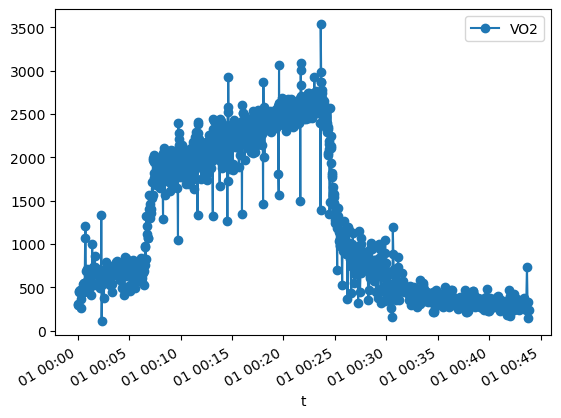

In [ ]:
participant_df['TR000101_20220331'].plot(x="t", y="VO2", kind = 'line', marker = "o")

In [53]:
#Testing Steady State Column
import warnings
warnings.simplefilter(action='ignore')
def find_best_window_size():
    for i in range(10,35):
        summaries = create_summaries_dfs(i)
        sum_true = 0
        sum_df_true = 0
        for key in summaries.keys():
            for key2 in summaries[key].keys():
                #print(f"{i},{key},{key2},{(summaries[key][key2]['Reach Steady State? T/F'] == True).sum() > 0}")
                sum_true += (summaries[key][key2]['Reach Steady State? T/F'] == True).sum()
                if (summaries[key][key2]['Reach Steady State? T/F'] == True).sum() > 0:
                    sum_df_true += 1
        
        print(f"window size = {i},total true values = {sum_true},total true dfs = {sum_df_true}")

#(summaries['TR000103'][2]['Reach Steady State? T/F'] == True).sum()
find_best_window_size()

Insufficient data for stage 5.0
Insufficient data for stage 4.0
Insufficient data for stage 5.0
Insufficient data for stage 1.0
Insufficient data for stage 7.0
Insufficient data for stage 8.0
Insufficient data for stage 1.0
Insufficient data for stage 2.0
Insufficient data for stage 1.0
Insufficient data for stage 1.0
Insufficient data for stage 3.0
Insufficient data for stage 6.0
Insufficient data for stage 7.0
Insufficient data for stage 7.0
Insufficient data for stage 1.0
Insufficient data for stage 2.0
Insufficient data for stage 1.0
Insufficient data for stage 3.0
Insufficient data for stage 7.0
Insufficient data for stage 2.0
Insufficient data for stage 1.0
Insufficient data for stage 1.0
Insufficient data for stage 2.0
Insufficient data for stage 9.0
Insufficient data for stage 9.0
Insufficient data for stage 1.0
Insufficient data for stage 3.0
Insufficient data for stage 2.0
Insufficient data for stage 3.0
Insufficient data for stage 9.0
Insufficient data for stage 5.0
Insuffic

KeyboardInterrupt: 

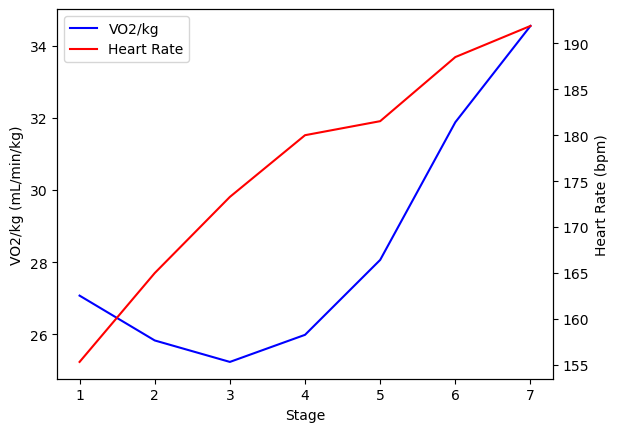

In [57]:
import matplotlib.pyplot as plt

data = summaries['TR000100'][1]

# Create the twin axis plot
fig, ax1 = plt.subplots()
ax2 = ax1.twinx()

# Plot VO2/kg on the first axis
ax1.plot(data['Stage (#)'], data['VO2 (mL/min/kg)'], 'b-', label='VO2/kg')
ax1.set_xlabel('Stage')
ax1.set_ylabel('VO2/kg (mL/min/kg)')

# Plot heart rate on the second axis
ax2.plot(data['Stage (#)'], data['HR (bpm)'], 'r-', label='Heart Rate')
ax2.set_ylabel('Heart Rate (bpm)')

# Set the legend
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper left')

# Show the plot
plt.show()






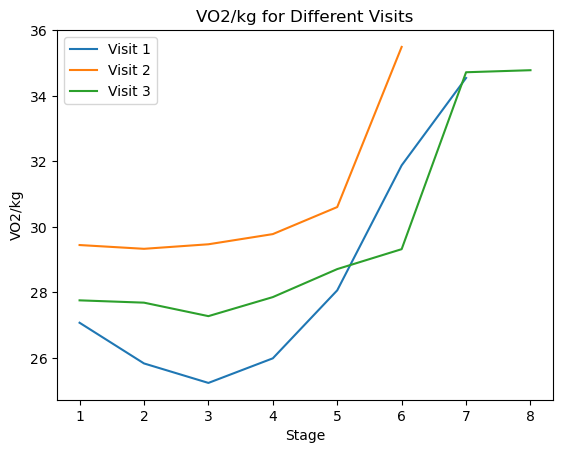

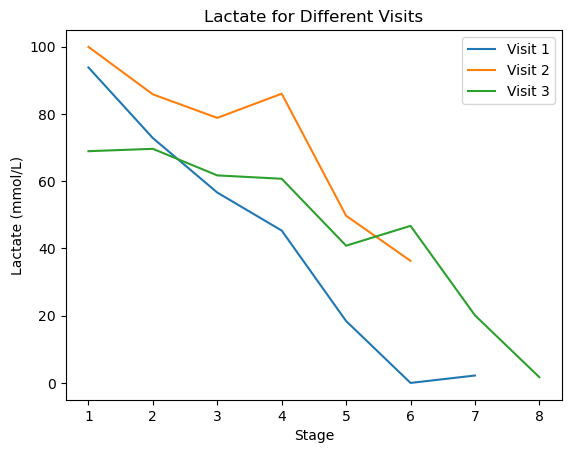

In [58]:
import matplotlib.pyplot as plt

# Get the summary tables for TR000100
summary_1 = summaries['TR000100'][1]
summary_2 = summaries['TR000100'][2]
summary_3 = summaries['TR000100'][3]

# Plot VO2/kg for each visit
plt.plot(summary_1['Stage (#)'], summary_1['VO2 (mL/min/kg)'], label='Visit 1')
plt.plot(summary_2['Stage (#)'], summary_2['VO2 (mL/min/kg)'], label='Visit 2')
plt.plot(summary_3['Stage (#)'], summary_3['VO2 (mL/min/kg)'], label='Visit 3')

# Set plot title and labels
plt.title('VO2/kg for Different Visits')
plt.xlabel('Stage')
plt.ylabel('VO2/kg')

# Add legend
plt.legend()

# Show the plot
plt.show()
plt.plot(summary_1['Stage (#)'], summary_1['Lactate (mmol/L)'], label='Visit 1')
plt.plot(summary_2['Stage (#)'], summary_2['Lactate (mmol/L)'], label='Visit 2')
plt.plot(summary_3['Stage (#)'], summary_3['Lactate (mmol/L)'], label='Visit 3')

# Set plot title and labels
plt.title('Lactate for Different Visits')
plt.xlabel('Stage')
plt.ylabel('Lactate (mmol/L)')

# Add legend
plt.legend()

# Show the plot
plt.show()



In [59]:
# Specify the time after which you want to get the first value
target_time = pd.to_datetime('1900-01-01 00:22:30')

# Filter the DataFrame based on the time condition and select the first value
first_value = VO2_outcome_df.loc[VO2_outcome_df['VO2Peak start time- local'] > target_time, 'VO2_peak'].iloc[0]

# Print the first value
print(first_value)


3453.436232052


In [62]:
def get_VO2_kg_peak(df_dictionary, result_df):
    id_list = list(result_df.index)
    for id in id_list:
        df = df_dictionary[id]
        
        # Convert 'timestamp' to seconds elapsed
        df['t'] = pd.to_datetime(df['t'])  # Convert to datetime
        start_time = df['t'].iloc[0]       # First timestamp as reference
        df['seconds_elapsed'] = (df['t'] - start_time).dt.total_seconds()

        
        # Initialize variables for tracking VO2_peak and VO2/kgPeak
        peak_value = float('-inf')
        peak_start_time = None
        peak_end_time = None
        kg_peak_value = None

        # Iterate through each row to compute the rolling mean based on a 30-second window
        for i, current_row in df.iterrows():
            current_time = current_row['seconds_elapsed']
            window_end = current_time
            window_start = current_time - 30
            
            # Select rows within the 30-second window
            window_data_VO2 = df[(df['seconds_elapsed'] >= window_start) & (df['seconds_elapsed'] <= window_end)]['VO2']
            rolling_mean_VO2 = window_data_VO2.mean()

            # Update the peak value and corresponding time window
            if rolling_mean_VO2 > peak_value:
                peak_value = rolling_mean_VO2
                peak_start_time = window_start
                peak_end_time = window_end

                # Find the rolling mean of the _16 column for the same interval
                window_data_16 = df[(df['seconds_elapsed'] >= window_start) & (df['seconds_elapsed'] <= window_end)]['_16']
                kg_peak_value = window_data_16.mean()

        # Convert seconds back to HH:MM:SS format
        def seconds_to_hhmmss(seconds):
            hours = seconds // 3600
            minutes = (seconds % 3600) // 60
            seconds = seconds % 60
            return f"{hours:02}:{minutes:02}:{seconds:02}"

        # Record results in the result DataFrame
        result_df.loc[id, 'VO2_peak'] = peak_value
        result_df.loc[id, 'VO2Peak start time- global'] = seconds_to_hhmmss(peak_start_time)
        result_df.loc[id, 'VO2Peak end time- global'] = seconds_to_hhmmss(peak_end_time)
        result_df.loc[id, 'VO2/kgPeak'] = kg_peak_value
    return result_df

VO2_outcome_df = get_VO2_kg_peak(participant_df, VO2_outcome_df)
VO2_outcome_df
   

TypeError: unsupported operand type(s) for //: 'NoneType' and 'int'

Index(['Index', 'participant_ID', 'visit_date', '_3', 't', 'Rf', 'VT', 'VE',
       'IV', 'VO2', 'VCO2', 'RQ', 'O2exp', 'CO2exp', '_14', '_15', '_16',
       'METS', 'HR', '_19', 'FeO2', 'FeCO2', 'FetO2', 'FetCO2', 'FiO2',
       'FiCO2', 'PeO2', 'PeCO2', 'PetO2', 'PetCO2', 'SpO2', 'Grade', 'Speed',
       'Phase', 'Marker', '_35', '_36', '_37', 'PB', 'EEkc', 'EEh', 'EEm',
       'EEtot', 'EEkg', 'PRO', 'Fat', 'CHO', '_47', '_48', '_49', 'npRQ',
       '_51', '_52', '_53', '_54', '_55', '_56', '_57', '_58', '_59', '_60',
       '_61', '_62', '_63', '_64', '_65', '_66', '_67', '_68', '_69', '_70',
       '_71', '_72', '_73', '_74', '_75', '_76', 'Ti', 'Te', 'Ttot', '_80',
       '_81', 'LogVE', '_83', '_84', '_85', '_86', '_87', 'BR', '_89', 'HRR',
       'PaCO2_e', 'Dyspnea', '_93', '_94'],
      dtype='object')

In [ ]:
#Create Result Dataframes
def create_results_dictionary(parent_df):
    """
    Creates a nested dictionary to store participant test results in a structured format.

    Args:
        parent_df (pd.DataFrame): DataFrame containing participant IDs and visit dates.

    Returns:
        dict: A dictionary where keys are unique participant-visit combinations and 
              values are empty pandas DataFrames with predefined columns and rows.
    """

    # Initialize an empty dictionary to store participants' visit data
    participant_registry = dict()

     # First loop: Initialize an empty dictionary for each participant ID
    for row in parent_df.itertuples():
        participant_registry[row.participant_ID] = dict()
    
     # Second loop: Initialize an empty list for each visit date within each participant's dictionary
    for row in parent_df.itertuples():
        participant_registry[row.participant_ID][row.visit_date] = []
    
     # Dictionary to store the final DataFrame results for each participant visit
    participant_result_df = dict()

     # Define the column names for the DataFrame (representing different exercise stages)
    columns = ["V02max", "LT1", "LT2", "VT1", "VT2", "Stage 1", "Stage 2", "Stage 3", "... Stage X"]

     # Define the row labels (representing different physiological metrics measured during testing)
    rows = [
        "VO2 (mL/min/kg)",
        "Velocity (km/h)",
        "Grade (%)",
        "Stage (#)",
        "RPE (#)",
        "HR (bpm)",
        "Lactate (mmol/L)",
        "RQ",
        "True VO2max? Y/N",
        "Reach Steady State?",
    ]

     # Loop through each participant and visit date to initialize an empty DataFrame for results
    for participant_id, participant_data in participant_registry.items():
        for visit_date in participant_data.keys():
            # Create an empty DataFrame with the predefined structure and store it in the dictionary
            participant_result_df[f'{participant_id}_{visit_date}'] = pd.DataFrame(columns=columns, index=rows)
    print(participant_df.keys())
    return participant_result_df

participant_result_df = create_results_dictionary(big_frame)
participant_result_df['TR000105_20220207']


dict_keys(['TR000105_20220207', 'TR000105_20220517', 'TR000105_20220920', 'TR000106_20220420', 'TR000106_20220208', 'TR000106_20220823', 'TR000102_20220204', 'TR000102_20220401', 'TR000102_20220630', 'TR000100_20220623', 'TR000100_20220331', 'TR000100_20220203', 'TR000104_20220627', 'TR000104_20220207', 'TR000104_20220314', 'TR000109_20220209', 'TR000109_20220824', 'TR000109_20220518', 'TR000107_20220519', 'TR000107_20220208', 'TR000107_20220805', 'TR000103_20220401', 'TR000103_20220204', 'TR000103_20220706', 'TR000101_20220203', 'TR000101_20220630', 'TR000101_20220331', 'TR000110_20220210', 'TR000110_20220428', 'TR000110_20220901', 'TR000108_20220209'])


,V02max,LT1,LT2,VT1,VT2,Stage 1,Stage 2,Stage 3,... Stage X
VO2 (mL/min/kg),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Velocity (km/h),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Grade (%),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Stage (#),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
RPE (#),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
HR (bpm),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Lactate (mmol/L),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
RQ,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
True VO2max? Y/N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Reach Steady State?,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
